In [52]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [53]:
recomb_df = pd.read_csv("../data/hs1_lifted_recomb.bed", sep="\t", names=["chrom", "start", "end", "cMperMb"])
recomb_df

,chrom,start,end,cMperMb
0,chr1,866173,877215,2.585239e-02
1,chr1,877247,878065,2.585239e-02
2,chr1,878065,888015,2.585239e-02
3,chr1,888016,903472,2.585239e-02
4,chr1,903472,912225,2.585239e-02
...,...,...,...,...
1857379,chrX,152993037,152993938,2.079851e-39
1857380,chrX,152993938,152998644,2.079851e-39
1857381,chrX,152998644,153005429,2.079851e-39
1857382,chrX,153005430,153006900,2.079851e-39


In [77]:
interval_size = 100000
df_l = []
for c_n in ["chrX"]: #recomb_df["chrom"].unique():
    chr_df = recomb_df.loc[recomb_df.chrom == c_n].copy()
    # Adding dummy breakpoints
    counter = 0
    breakpoint_list = list(range(0, chr_df.end.iloc[-1]+interval_size,interval_size))
    start_l, end_l, cM_l = [], [], []
    for i, j in zip(chr_df.start, chr_df.cMperMb):
        if i+interval_size >= breakpoint_list[counter]:
            start_l.append(breakpoint_list[counter])
            end_l.append(breakpoint_list[counter]+)
            counter += 1
            cM_l.append(j)
            if counter == len(breakpoint_list):
                break
    breakpoint_df = pd.DataFrame({"start": start_l, "cMperMb": cM_l})
    chr_df = pd.concat()
    chr_df = chr_df.sort_values(by="start")
    chr_df["window_size"] = chr_df.end-chr_df.start
    chr_df["midpoint"] = chr_df["window_size"]/2+chr_df.start
    chr_df["window_100kb"] = pd.cut(chr_df.midpoint, list(range(0, chr_df.end.iloc[-1]+interval_size,
                                                             interval_size)), labels=False)*interval_size
    chr_df["cM"] = (chr_df.cMperMb*chr_df.window_size)
    summed_recomb = (chr_df.groupby(["chrom", "window_100kb"])[["cM"]].sum()).reset_index()
    summed_recomb["mapped_bases"] = chr_df.groupby(["window_100kb"])[["window_size"]].sum().reset_index()["window_size"]
    summed_recomb["cMperMb"] = summed_recomb.cM/summed_recomb.mapped_bases
    df_l.append(summed_recomb)
recomb_df_100kb = pd.concat(df_l)

In [88]:
counter = 0
breakpoint_list = list(range(0, chr_df.end.iloc[-1]+interval_size,interval_size))
start_l, cM_l = [], []
for i, j in zip(chr_df.start, chr_df.cMperMb):
    if i+interval_size >= breakpoint_list[counter]:
        start_l.append(breakpoint_list[counter])
        counter += 1
        cM_l.append(j)
        if counter == len(breakpoint_list):
            break

In [92]:
len(start_l), len(breakpoint_list), len(cM_l)

(1532, 1532, 1532)

[Text(0.5, 0, '100kb windows'), Text(0, 0.5, 'cM per Mb')]

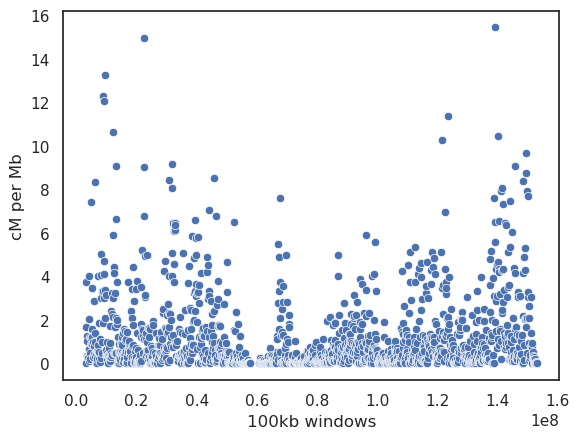

In [69]:
g = sns.scatterplot(recomb_df_100kb.loc[recomb_df_100kb.chrom == "chrX"],
                    x="window_100kb", y="cMperMb")
g.set(xlabel="100kb windows", ylabel="cM per Mb")

In [96]:
interval_size = 1000000
df_l = []
for c_n in ["chrX"]: #recomb_df["chrom"].unique():
    chr_df = recomb_df.loc[recomb_df.chrom == c_n].copy()
    breakpoint_df = pd.DataFrame({"start": start_l, "cMperMb": cM_l})
    chr_df = chr_df.sort_values(by="start")
    chr_df["window_size"] = chr_df.end-chr_df.start
    chr_df["midpoint"] = chr_df["window_size"]/2+chr_df.start
    chr_df["window_1mb"] = pd.cut(chr_df.midpoint, list(range(0, chr_df.end.iloc[-1]+interval_size,
                                                             interval_size)), labels=False)*interval_size
    chr_df["cM"] = (chr_df.cMperMb*chr_df.window_size)
    summed_recomb = (chr_df.groupby(["chrom", "window_1mb"])[["cM"]].sum()).reset_index()
    summed_recomb["mapped_bases"] = chr_df.groupby(["window_1mb"])[["window_size"]].sum().reset_index()["window_size"]
    summed_recomb["cMperMb"] = summed_recomb.cM/summed_recomb.mapped_bases
    df_l.append(summed_recomb)
recomb_df_1Mb = pd.concat(df_l)

In [99]:
recomb_df_1Mb.to_csv("../data/hs1_1Mb_recomb.txt", sep="\t", index=False)

[Text(0.5, 0, '1Mb windows'), Text(0, 0.5, 'cM per Mb')]

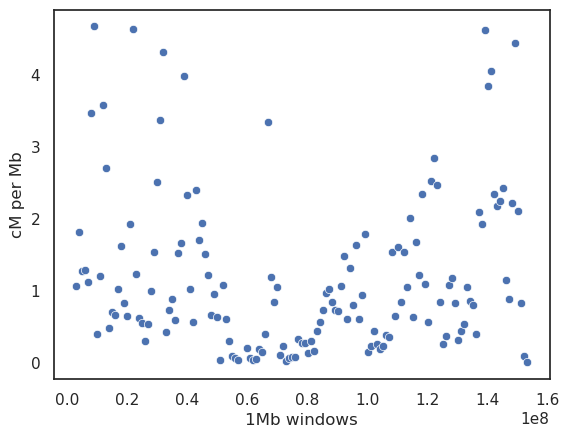

In [97]:
g = sns.scatterplot(recomb_df_1Mb.loc[recomb_df_1Mb.chrom == "chrX"],
                    x="window_1mb", y="cMperMb")
g.set(xlabel="1Mb windows", ylabel="cM per Mb")

In [47]:
recomb_df_hg38 = pd.read_csv("../data/recomb_bed.bed", sep="\t", names=["chrom", "start", "end", "cMperMb"])
recomb_df_hg38

,chrom,start,end,cMperMb
0,chr1,1431813,1515567,2.585239e-02
1,chr1,1515567,1530002,4.740767e-02
2,chr1,1530002,1534402,1.700061e-03
3,chr1,1534402,1538787,7.231869e-03
4,chr1,1538787,1541864,7.787222e-06
...,...,...,...,...
1146928,chrX,154496001,154664593,7.542684e-02
1146929,chrX,154664593,154676196,2.530884e-22
1146930,chrX,154676196,154680555,8.751389e-36
1146931,chrX,154680555,154717327,2.145439e-39


In [61]:
interval_size = 100000
df_l = []
for c_n in ["chrX"]: #recomb_df["chrom"].unique():
    chr_df = recomb_df_hg38.loc[recomb_df_hg38.chrom == c_n].copy()
    chr_df = chr_df.sort_values(by="start")
    chr_df["window_size"] = chr_df.end-chr_df.start
    chr_df["midpoint"] = chr_df["window_size"]/2+chr_df.start
    chr_df["window_100kb"] = pd.cut(chr_df.midpoint, list(range(0, chr_df.end.iloc[-1]+interval_size,
                                                             interval_size)), labels=False)*interval_size
    chr_df["cM"] = (chr_df.cMperMb*chr_df.window_size)
    summed_recomb = (chr_df.groupby(["chrom", "window_100kb"])[["cM"]].sum()).reset_index()
    summed_recomb["mapped_bases"] = chr_df.groupby(["window_100kb"])[["window_size"]].sum().reset_index()["window_size"]
    summed_recomb["cMperMb"] = summed_recomb.cM/summed_recomb.mapped_bases
    df_l.append(summed_recomb)
recomb_df_100kb_hg38 = pd.concat(df_l)

In [70]:
chr_df.window_size.max()

3095089

In [63]:
recomb_df_100kb_hg38

,chrom,window_100kb,cM,mapped_bases,cMperMb
0,chrX,3500000,1.109579e+04,67809,1.636329e-01
1,chrX,3600000,2.213949e+05,99756,2.219365e+00
2,chrX,3700000,3.925268e+05,100174,3.918450e+00
3,chrX,3800000,1.201209e+05,104816,1.146017e+00
4,chrX,3900000,9.237371e+04,107656,8.580452e-01
...,...,...,...,...,...
1455,chrX,154300000,1.978732e+04,103146,1.918380e-01
1456,chrX,154400000,2.157748e-01,97604,2.210717e-06
1457,chrX,154500000,1.271636e+04,168592,7.542684e-02
1458,chrX,154600000,2.936584e-18,52734,5.568674e-23


[Text(0.5, 0, '100kb windows'), Text(0, 0.5, 'cM per Mb')]

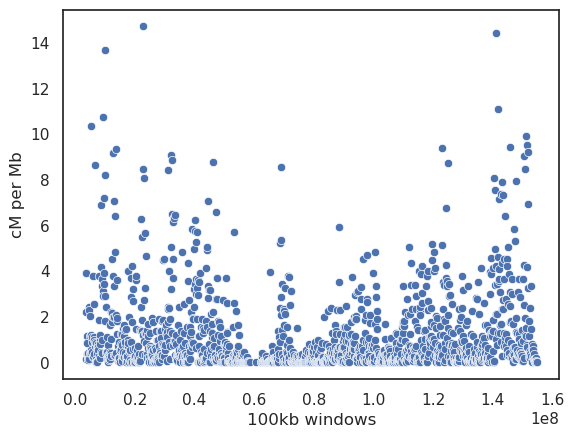

In [64]:
g = sns.scatterplot(recomb_df_100kb_hg38.loc[recomb_df_100kb_hg38.chrom == "chrX"], x="window_100kb", y="cMperMb")
g.set(xlabel="100kb windows", ylabel="cM per Mb")